<a href="https://www.kaggle.com/code/sonawanelalitsunil/facttext-verified-facts-collection-ml-99-92?scriptVersionId=224605121" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/facts-textual-dataset/Facts_reddit_Dataset.csv


## Title: "FactText: A Collection of Verified Factual Statements"

**Dataset Description:
The FactText dataset is a structured collection of textual statements that present factual information across various domains such as history, science, geography, technology, and more. Each entry consists of a factually accurate sentence or paragraph, potentially accompanied by metadata such as category, source credibility, date of verification, and confidence scores. This dataset can be useful for tasks like fact-checking, knowledge graph construction, natural language understanding (NLU), and training AI models for factual consistency.**

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [3]:
df = pd.read_csv("/kaggle/input/facts-textual-dataset/Facts_reddit_Dataset.csv")

In [4]:
df.head()

,Unnamed: 0,title,score
0,0,that George Metesky (aka the Mad Bomber) terro...,99
1,1,that even though September is not the most com...,41
2,2,that a boy saw 17 doctors over the course of t...,0
3,3,Theodore Roosevelt was shot during a speech an...,1000
4,4,that only 48.5% of adults reported reading at ...,572


In [5]:
df.tail()

,Unnamed: 0,title,score
19995,19995,Pistachio used to by dyed red so they looked m...,128
19996,19996,in 1997 an Air Force pilot mysteriously crashe...,6855
19997,19997,Leontyne Price was the first African American ...,271
19998,19998,There isn’t a single stop sign in Paris,20068
19999,19999,Today I learned that women's soccer was banned...,751


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  20000 non-null  int64 
 1   title       20000 non-null  object
 2   score       20000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 468.9+ KB


In [7]:
df.describe()

,Unnamed: 0,score
count,20000.000000,20000.000000
mean,9999.500000,5216.712000
std,5773.647028,9808.371118
min,0.000000,0.000000
25%,4999.750000,243.750000
50%,9999.500000,1080.500000
75%,14999.250000,5251.250000
max,19999.000000,74436.000000


In [8]:
df.shape

(20000, 3)

In [9]:
df.isnull().sum()

Unnamed: 0    0
title         0
score         0
dtype: int64

In [10]:
df.columns

Index(['Unnamed: 0', 'title', 'score'], dtype='object')

In [11]:
df['score'] = pd.to_numeric(df['score'], errors='coerce')

In [12]:
median_score = df['score'].median()
df['Popularity'] = (df['score'] > median_score).astype(int)

In [13]:
print(f"Median score value: {median_score}")

Median score value: 1080.5


## Data visulization

In [14]:
# Drop unnamed index column if present
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

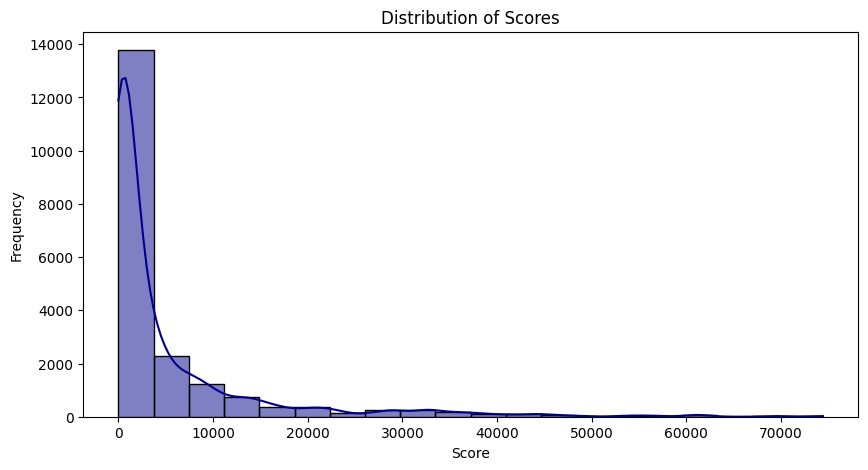

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df['score'], kde=True, bins=20, color='darkblue')
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Scores")
plt.show()

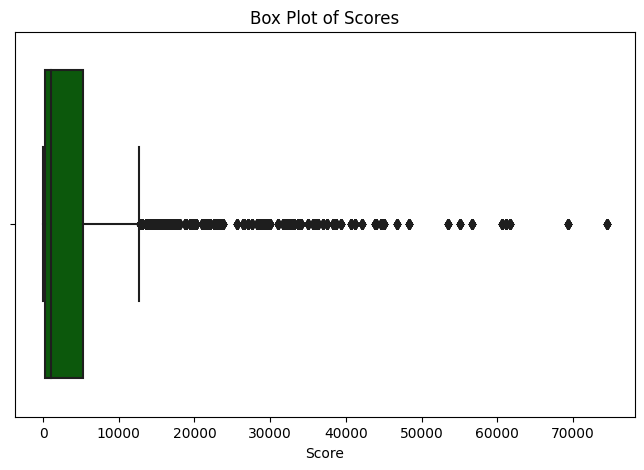

In [16]:
# 2️⃣ Box Plot of Scores
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['score'], color='darkgreen')
plt.xlabel("Score")
plt.title("Box Plot of Scores")
plt.show()

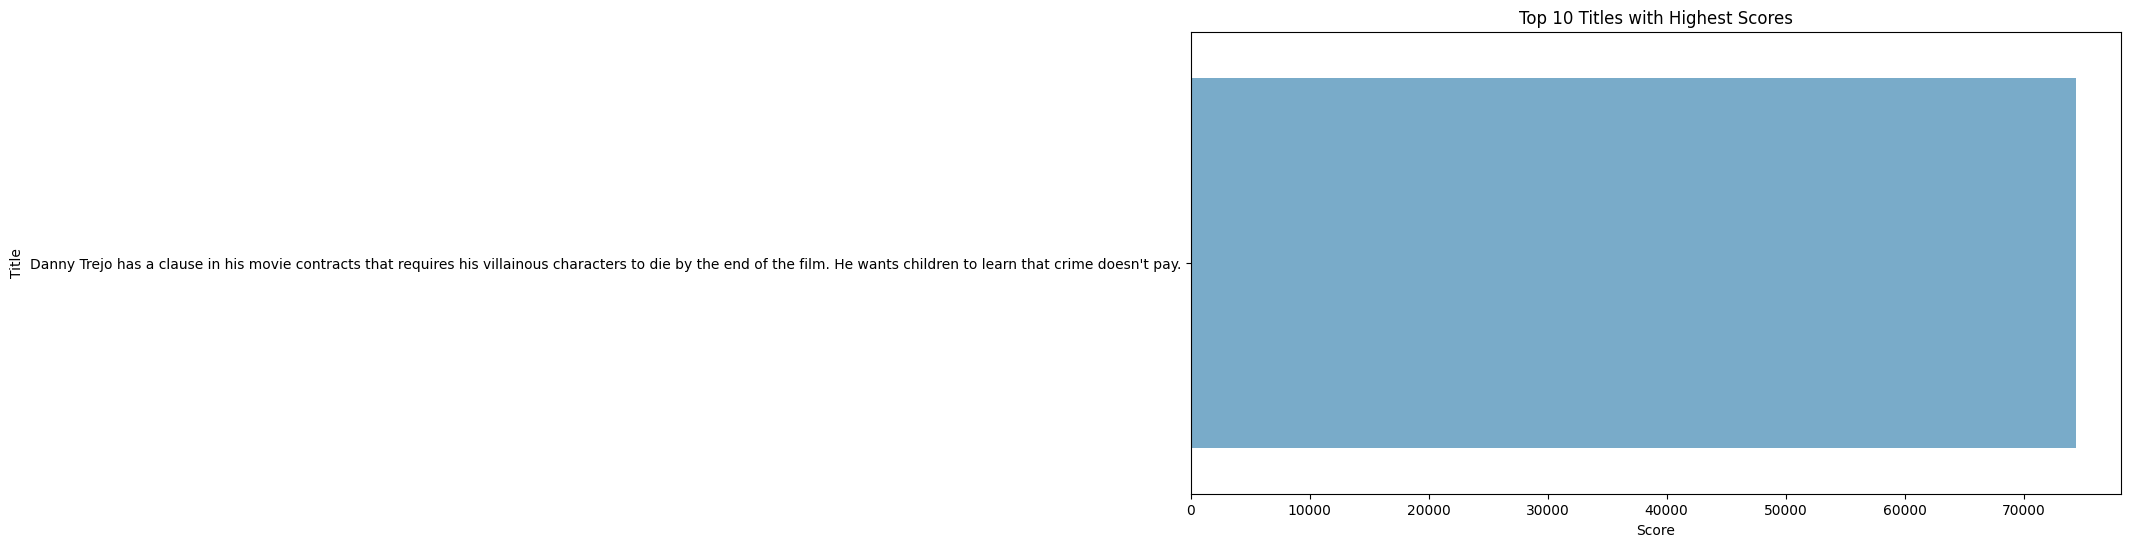

In [17]:
# 3️⃣ Top N Titles with Highest Scores
N = 10
top_titles = df.nlargest(N, 'score')
plt.figure(figsize=(12, 6))
sns.barplot(y=top_titles['title'], x=top_titles['score'], palette='Blues_r')
plt.xlabel("Score")
plt.ylabel("Title")
plt.title(f"Top {N} Titles with Highest Scores")
plt.show()

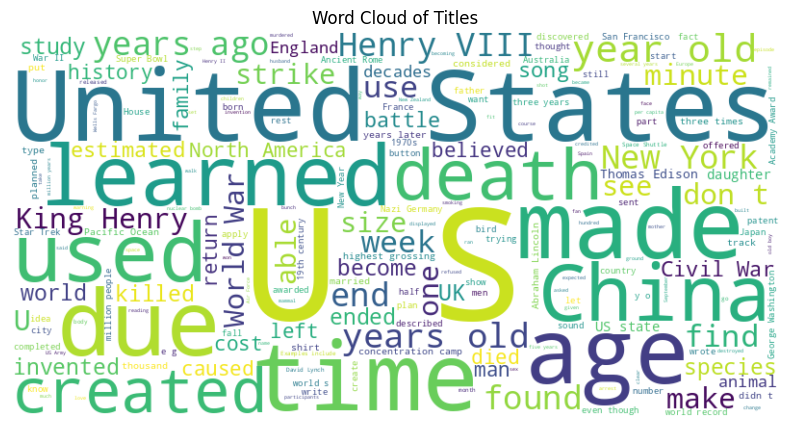

In [18]:
from wordcloud import WordCloud
# 4️⃣ Word Cloud of Titles
text = " ".join(df['title'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Titles")
plt.show()

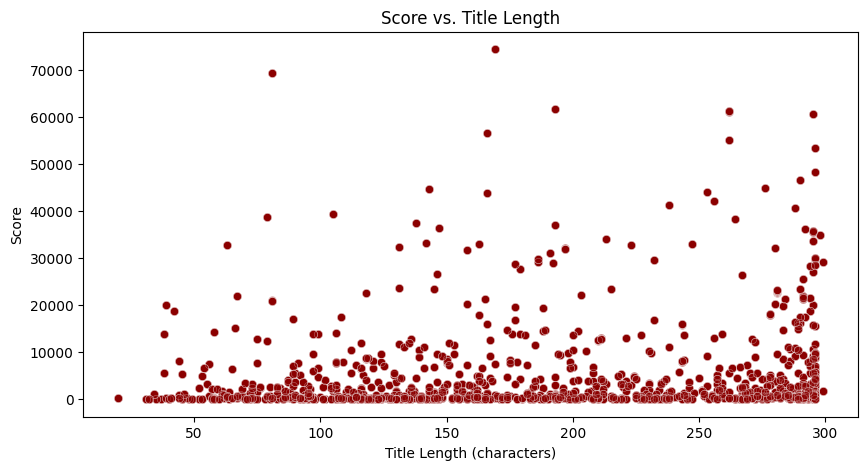

In [19]:
# 5️⃣ Score vs. Title Length (Scatter Plot)
df['title_length'] = df['title'].astype(str).apply(len)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['title_length'], y=df['score'], alpha=0.5, color='darkred')
plt.xlabel("Title Length (characters)")
plt.ylabel("Score")
plt.title("Score vs. Title Length")
plt.show()

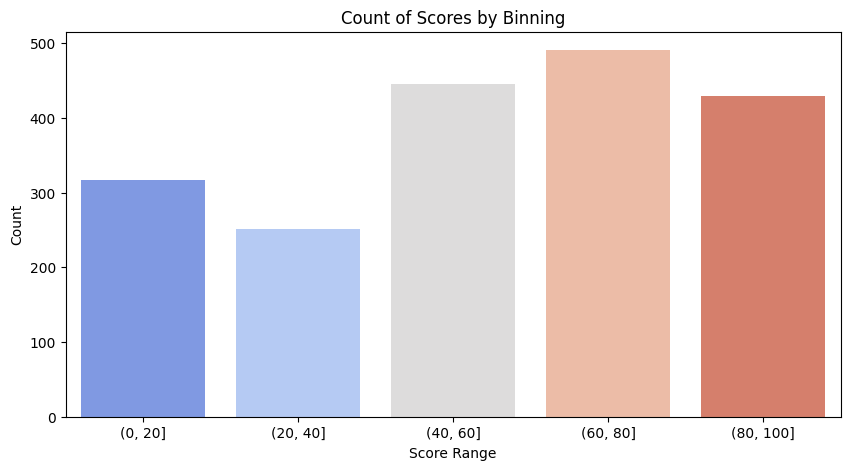

In [20]:
# 6️⃣ Count of Scores by Binning (Bar Chart)
df['score_bins'] = pd.cut(df['score'], bins=[0, 20, 40, 60, 80, 100])
plt.figure(figsize=(10, 5))
sns.countplot(x=df['score_bins'], palette='coolwarm')
plt.xlabel("Score Range")
plt.ylabel("Count")
plt.title("Count of Scores by Binning")
plt.show()

## ML Algorithms

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [22]:
X = df['title']
y = df['Popularity']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
from sklearn.pipeline import Pipeline

In [25]:
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


Logistic Regression Accuracy: 0.9992
Random Forest Accuracy: 0.9992
Support Vector Machine Accuracy: 0.9992
Naïve Bayes Accuracy: 0.9992
Gradient Boosting Accuracy: 0.8635


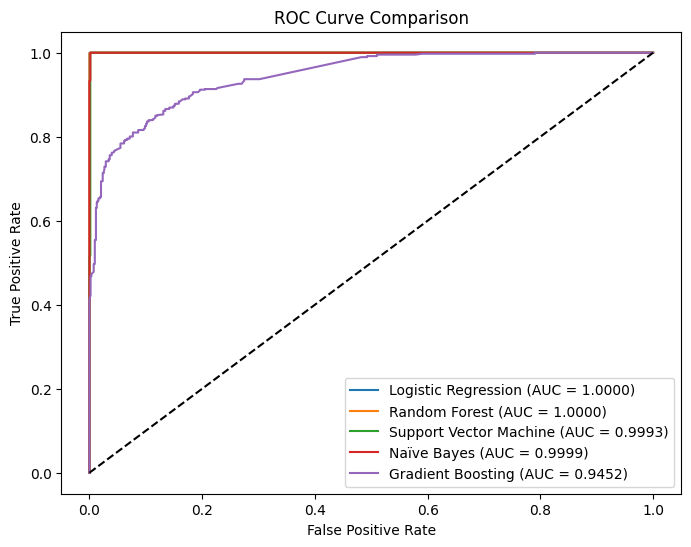


Model Performance Summary:
Logistic Regression: 0.9992
Random Forest: 0.9992
Support Vector Machine: 0.9992
Naïve Bayes: 0.9992
Gradient Boosting: 0.8635


In [26]:
X = df['title']
y = df['Popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Naïve Bayes': MultinomialNB(),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Iterate through models and evaluate
results = {}
plt.figure(figsize=(8, 6))
for name, model in models.items():
    pipeline = Pipeline([
        ('vectorizer', CountVectorizer()),
        ('classifier', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    
    # Compute ROC curve and AUC
    if hasattr(model, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Print model performances
print("\nModel Performance Summary:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


## Thank you....pls Upvotes..